In [1]:
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp
import seaborn as sns
import matplotlib.pyplot as plt
import os
import arviz as az
import pickle as pkl
import json

In [2]:
#df_Nfd = pd.read_csv('/home/apoorva/Desktop/work/MZ_analysis/data/total_mzcounts_sorted.csv')
df_new = pd.read_csv('/home/apoorva/Desktop/work/MZ_analysis/data/New_data/new_data_MZB.csv')
df_ont = pd.read_csv('/home/apoorva/Desktop/work/MZ_analysis/data/New_data/ontogeny_counts.csv')


file_path = '/home/apoorva/Desktop/work/MZ_analysis/data/New output (pkl)/Ontogeny Output/TDM/TDM_loss_T2.pkl'
if os.path.getsize(file_path) > 0:
    with open(file_path, 'rb') as f:
        data_neutral = pkl.load(f)
else:
    raise EOFError("File is empty")
# print(df_new.head(10))
# print(df_ont.head(10))

/tmp/ipykernel_3796703/2179966832.py:12: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0, 800)


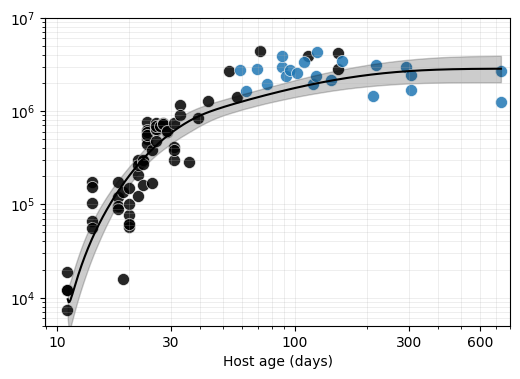

In [3]:
ts1 = np.arange(11.1, 732.1, 0.1)

# Plot the Mz counts
fig = plt.figure(figsize=(6, 4))
sns.scatterplot(data=df_ont, x='age.at.S1K', y='MZ_total', alpha=0.85, s=75, color= 'Black',label='Young WT mice', legend=False, linewidth=0.5)
sns.scatterplot(data=df_new, x='Age at S1K', y='total_MZ', alpha=0.85 ,s=75, label='Chimera', legend=False, linewidth=0.5)
plt.plot(ts1, np.mean(data_neutral.MZ_counts_pred, axis=0), color= 'black')
plt.fill_between(ts1, np.percentile(data_neutral.MZ_counts_pred, 2.5, axis=0), np.percentile(data_neutral.MZ_counts_pred, 97.5, axis=0), alpha=0.2, color='black')
plt.xscale('log')
plt.yscale('log')
plt.ylim(5*1e3, 1e7)
plt.xlim(0, 800)
# plt.xticks([10, 30, 100, 300, 600])
plt.xticks([10, 30, 100, 300, 600], [10, 30, 100, 300, 600])
plt.xlabel('Host age (days)')
plt.ylabel('')
plt.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
# plt.legend()
plt.show()

# Save the figure
# fig.savefig('/home/apoorva/Desktop/work/MZ_analysis/figures/Ontogeny/TDM_loss_FO.png', dpi=300)



array([<Axes: title={'center': 'phi'}>, <Axes: title={'center': 'r_lam'}>,
       <Axes: title={'center': 'lam'}>, <Axes: title={'center': 't0'}>],
      dtype=object)

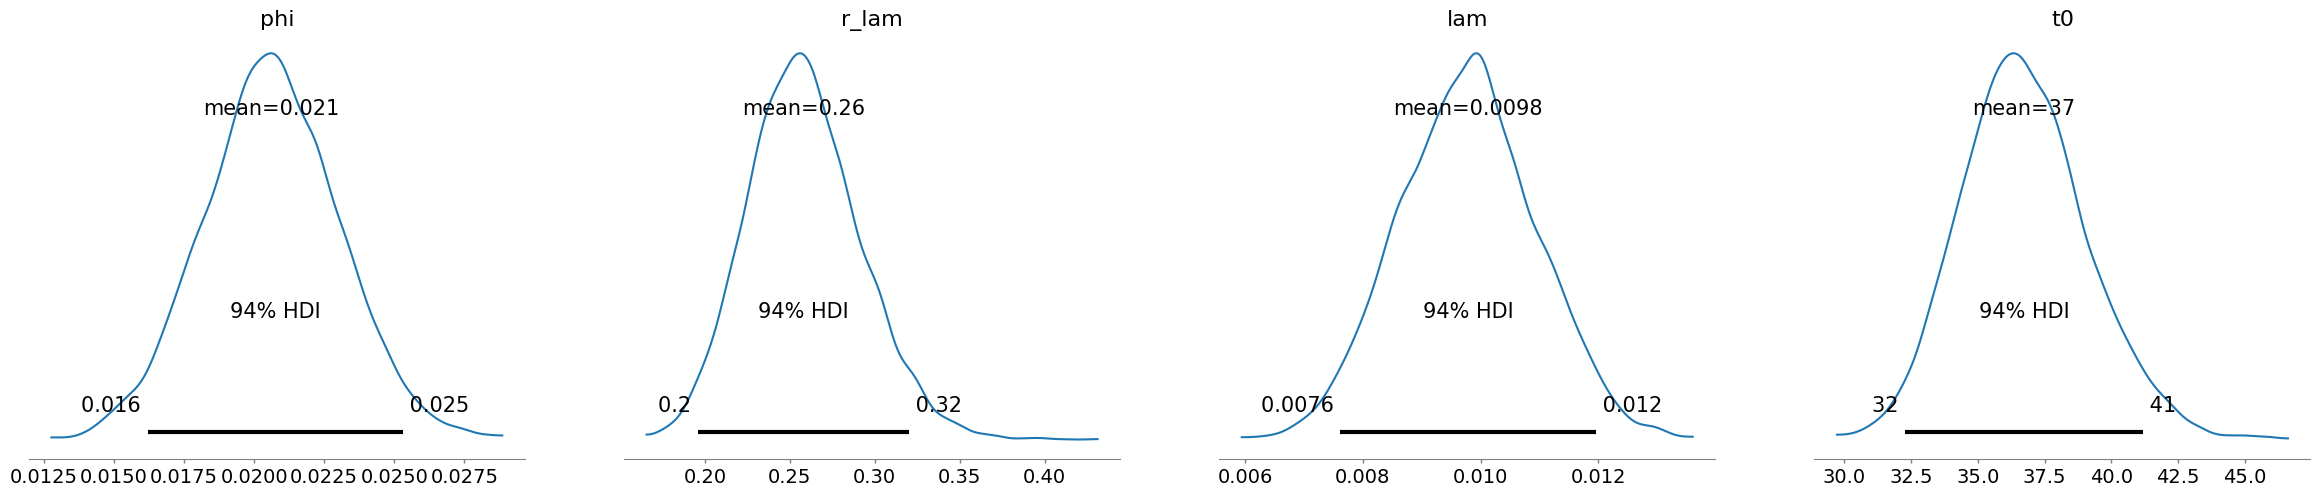

In [4]:
# Posterior distribution of parameters

az.plot_posterior(data_neutral, var_names=['phi', 'r_lam','lam', 't0'], kind='kde')

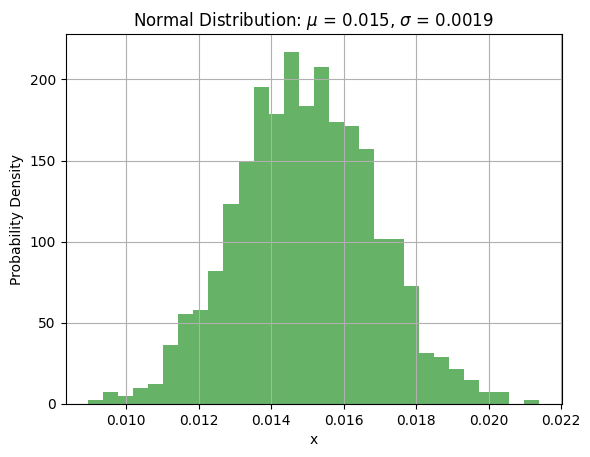

In [5]:
#Plot normaal prior for r_lam 

from matplotlib.pylab import normal
import scipy.stats as stats

# Parameters for the normal distribution
mu = 0.015
sigma = 0.0019
sample_size=1000

np.random.normal(mu, sigma, sample_size)

#Plot the distribution
plt.hist(np.random.normal(mu, sigma, sample_size), bins=30, density=True, alpha=0.6, color='g')
plt.title('Normal Distribution: $\mu$ = 0.015, $\sigma$ = 0.0019')
plt.xlabel('x')
plt.ylabel('Probability Density')
plt.grid()
plt.show()




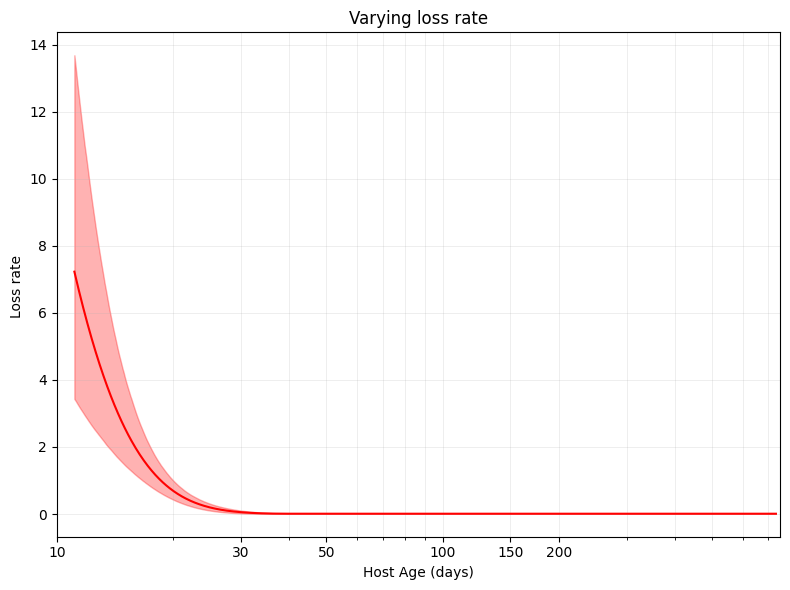

In [6]:
fig, axes = plt.subplots(1, 1, figsize=(8, 6))
axes.plot(ts1, np.mean(data_neutral.loss_rate_pred, axis=0), color='red')
axes.fill_between(ts1, np.quantile(data_neutral.loss_rate_pred, 0.025, axis=0), np.quantile(data_neutral.loss_rate_pred, 0.975, axis=0), alpha=0.3, color='red')
# axes.set_ylim(0, 0.05)
# axes.set_yscale('log')
# axes.set_yticks([0, 0.005, 0.01, 0.015, 0.02])
# axes.set_yticklabels([0, 0.005, 0.01, 0.015, 0.02])
axes.set_xscale('log')
axes.set_xlim(10, 750)
axes.set_xticks([10, 30, 50, 100, 150, 200])
axes.set_xticklabels([10, 30,  50, 100, 150, 200])
axes.set_ylabel('Loss rate ')
axes.set_xlabel('Host Age (days)')
axes.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
axes.set_title('Varying loss rate')
plt.tight_layout()
plt.show()

In [7]:
def lambda_func(t, r_lam):
    if(t <= 40):
     lam_var = 0.009 / ( 1+ np.exp(r_lam * (t-40)))
    else:
     lam_var = 0.009 
    return(lam_var)


def P(t):

    theta_0 = np.exp(14.17)
    nu = 0.27
    n = 1.96
    return theta_0 * (1 + (t-10)**n * np.exp(-nu * (t-10)))

# def phi(t, phi, r_phi):
#     return phi * np.exp(-r_phi * (t - 10))

t = np.arange(11, 750, 1)

# influx_p = np.zeros((8000, 739))
# for i in range(0, len(data_neutral.MZ_counts_pred[0])):
#     influx_p[:, i] = (phi(i, data_neutral.phi, data_neutral.r_phi) * P(i)) / data_neutral.MZ_counts_pred[:, i]

loss_rate = np.zeros((8000, 739))
for i in range(0, 739):
    loss_rate[:, i] = lambda_func(i, data_neutral.r_lam)
 


<Axes: title={'center': 'r_lam'}>

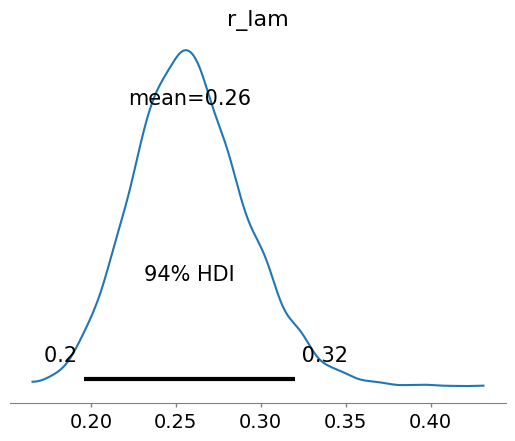

In [8]:
# Plot posteriors

az.plot_posterior(data_neutral, var_names=["r_lam"], kind='kde')